## Deepfake Video detection using Pretrained Model and LSTM


from google.colab import drive
drive.mount('/content/drive')# STARTS FROM HERE


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# common modules imoprts
import json
import glob
import numpy as np
import cv2
import copy
import os


In [ ]:
# use this to unzip your data
!unzip /content/drive/MyDrive/all_videos.zip
# !unzip /content/Face_only_data.zip

In [ ]:
#To get the average frame count

video_files =  glob.glob('/content/FF_Face_only_data/*.mp4')
frame_count = []
for video_file in video_files:
  cap = cv2.VideoCapture(video_file)
  if(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))<150):
    video_files.remove(video_file)
    continue
  frame_count.append(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("frames" , frame_count)
print("Total number of videos: " , len(frame_count))
print('Average frame per video:',np.mean(frame_count))

frames []
Total number of videos:  0
Average frame per video: nan


In [ ]:
# to extract frame
def frame_extract(path):
  vidObj = cv2.VideoCapture(path)
  success = 1
  while success:
      success, image = vidObj.read()
      if success:
          yield image

!mkdir '/content/Face_only_data'


In [ ]:
# import torch API along with face_recognition API
!pip install face_recognition --quiet
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset

import warnings
import matplotlib.pyplot as plt
import face_recognition  # requires CUDA installation. make sure to install cude for this
from tqdm.autonotebook import tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# process the frames
def create_face_videos(path_list,out_dir):
  '''
   that takes a list of paths to video files (path_list) and an output directory (out_dir).
   It processes each video file to extract frames and detect faces in those frames. Then,
   it creates a new video containing only the detected faces and saves it in the output directory
   Breakdown of code:
   1. It checks how many videos are already present in the output directory and prints the count.
   2. It constructs the output path by joining the output directory with the filename of the video.
   3. It checks if the output file already exists. If it does, it skips processing that video.
   4. It initializes an empty list frames to store frames of the video.
   5. It initializes an OpenCV VideoWriter object to write the output video.
   6. It iterates over each frame of the video:
     6.1 It appends the frame to the frames list.
     6.2 If the length of frames is equal to 4 (indicating that 4 frames have been collected), it detects faces in those frames using the face_recognition library.
     6.3 It extracts the detected faces from the frames, resizes them to a standard size (112x112 pixels), and writes them to the output video.

   7. Finally, it releases the video writer object and cleans up any variables created during the process.

  '''

  already_present_count =  glob.glob(out_dir+'/content/FF_Face_only_data/*.mp4')
  print("No of videos already present " , len(already_present_count))
  for path in tqdm(path_list):
    out_path = os.path.join(out_dir,path.split('/')[-1])
    file_exists = glob.glob(out_path)
    if(len(file_exists) != 0):
      print("File Already exists: " , out_path)
      continue
    frames = []
    flag = 0
    face_all = []
    frames1 = []
    out = cv2.VideoWriter(out_path,cv2.VideoWriter_fourcc('M','J','P','G'), 30, (112,112))
    for idx,frame in enumerate(frame_extract(path)):
      #if(idx % 3 == 0):
      if(idx <= 150):
        frames.append(frame)
        if(len(frames) == 4):
          faces = face_recognition.batch_face_locations(frames)
          for i,face in enumerate(faces):
            if(len(face) != 0):
              top,right,bottom,left = face[0]
            try:
              out.write(cv2.resize(frames[i][top:bottom,left:right,:],(112,112)))
            except:
              pass
          frames = []
    try:
      del top,right,bottom,left
    except:
      pass
    out.release()

In [ ]:
# calling the function on our data directory
create_face_videos(video_files,'/content/FF_Face_only_data')  # writing all face crop vidoes in our new directory

NameError: name 'video_files' is not defined

In [ ]:
# only use to save data to your system.

from google.colab import files
import shutil

shutil.make_archive("Face_only_data", 'zip', "Face_only_data")
files.download("Face_only_data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## if we have faces extracted then we can start from here

In [ ]:
!unzip /content/drive/MyDrive/FF_Face_only_data.zip

### checking if some files are corrupted

In [ ]:
#If the video is corrupted delete the video.
#Check if the file is corrupted or not
def validate_video(vid_path,train_transforms):
      '''
      This function takes the path of a video file (vid_path) and a set of transformations (train_transforms) as inputs.
      It extracts frames from the video, applies the transformations, stacks them together, and returns them.
      It ensures that only a fixed number of frames (specified by the count variable) are extracted from the video.
      The function relies on the frame_extract generator to extract frames from the video.

      '''

      transform = train_transforms
      count = 20
      video_path = vid_path
      frames = []
      a = int(100/count)
      first_frame = np.random.randint(0,a)
      temp_video = video_path.split('/')[-1]
      for i,frame in enumerate(frame_extract(video_path)):
        frames.append(transform(frame))
        if(len(frames) == count):
          break
      frames = torch.stack(frames)
      frames = frames[:count]
      return frames
#extract a from from video
def frame_extract(path):

  '''
  This is a generator function that yields frames extracted from a video file located at the given path.
  It uses OpenCV's VideoCapture to read frames from the video.

  '''

  vidObj = cv2.VideoCapture(path)
  success = 1
  while success:
      success, image = vidObj.read()
      if success:
          yield image

im_size = 112
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
                                        transforms.ToPILImage(),
                                        transforms.Resize((im_size,im_size)),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean,std)])
video_fil =  glob.glob('/content/FF_Face_only_data/*.mp4')
print("Total no of videos :" , len(video_fil))
print(video_fil)
count = 0;
for i in video_fil:
  try:
    count+=1
    validate_video(i,train_transforms)
  except:
    print("Number of video processed: " , count ," Remaining : " , (len(video_fil) - count))
    print("Corrupted video is : " , i)
    continue
print((len(video_fil) - count))

Total no of videos : 6450
['/content/FF_Face_only_data/id3_id6_0006.mp4', '/content/FF_Face_only_data/785.mp4', '/content/FF_Face_only_data/id50_id53_0000.mp4', '/content/FF_Face_only_data/id26_0002.mp4', '/content/FF_Face_only_data/id53_0001.mp4', '/content/FF_Face_only_data/agvtpygfdc.mp4', '/content/FF_Face_only_data/bilwtjqxak.mp4', '/content/FF_Face_only_data/accuranbpc.mp4', '/content/FF_Face_only_data/ahcbiribgn.mp4', '/content/FF_Face_only_data/406.mp4', '/content/FF_Face_only_data/almnilnfyu.mp4', '/content/FF_Face_only_data/koowljkerd.mp4', '/content/FF_Face_only_data/ddgubuafql.mp4', '/content/FF_Face_only_data/zcijgqopyg.mp4', '/content/FF_Face_only_data/id58_id54_0002.mp4', '/content/FF_Face_only_data/rtcnwhskkw.mp4', '/content/FF_Face_only_data/todvzqzwit.mp4', '/content/FF_Face_only_data/845_846.mp4', '/content/FF_Face_only_data/bqkjvmuhkq.mp4', '/content/FF_Face_only_data/fnaajvgmwt.mp4', '/content/FF_Face_only_data/cbywmlmeds.mp4', '/content/FF_Face_only_data/062.mp4',

In [ ]:
import random
video_files =  glob.glob('/content/FF_Face_only_data/*.mp4')

random.shuffle(video_files)
random.shuffle(video_files)
frame_count = []
for video_file in video_files:
  cap = cv2.VideoCapture(video_file)
  if(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))<100):
    video_files.remove(video_file)
    continue
  frame_count.append(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("frames are " , frame_count)
print("Total no of video: " , len(frame_count))
print('Average frame per video:',np.mean(frame_count))


frames are  [148, 148, 148, 148, 147, 148, 148, 148, 104, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 113, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 147, 148, 148, 142, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 14

### extracting labels from .csv file and encode them as 0 and 1 for fake and real

In [ ]:
# load the video name and labels from csv

class video_dataset(Dataset):
    def __init__(self,video_names,labels,sequence_length = 60,transform = None):
        '''
        Initializes the dataset with video names, corresponding labels, sequence length (number of frames per video),
        and an optional transform (image preprocessing pipeline).

        '''

        self.video_names = video_names
        self.labels = labels
        self.transform = transform
        self.count = sequence_length
    def __len__(self):

        '''
        __len__(self): Returns the total number of videos in the dataset.
        '''

        return len(self.video_names)

    def __getitem__(self,idx):
        '''
        Retrieves the video frames and label for a given index idx. It performs the following steps:
        1. Retrieves the video path based on the index.
        2. Generates frames from the video using the frame_extract method.
        3. Extracts the label associated with the video from the provided labels dataframe.
        4. Converts the label to numerical format (0 for 'FAKE' and 1 for 'REAL').
        5. Applies the transformation to each frame.
        6. Stacks the transformed frames and returns them along with the label.

        '''

        video_path = self.video_names[idx]
        frames = []
        a = int(100/self.count)
        first_frame = np.random.randint(0,a)
        temp_video = video_path.split('/')[-1]
        #print(temp_video)
        label = self.labels.iloc[(labels.loc[labels["file"] == temp_video].index.values[0]),1]
        if(label == 'FAKE'):
          label = 0
        if(label == 'REAL'):
          label = 1
        for i,frame in enumerate(self.frame_extract(video_path)):
          frames.append(self.transform(frame))
          if(len(frames) == self.count):
            break
        frames = torch.stack(frames)
        frames = frames[:self.count]
        #print("length:" , len(frames), "label",label)
        return frames,label
    def frame_extract(self,path):

        '''
        A helper method to extract frames from a video file located at the given path. It yields individual frames using OpenCV's VideoCapture.

        '''

        vidObj = cv2.VideoCapture(path)
        success = 1
        while success:
            success, image = vidObj.read()
            if success:
                yield image


In [ ]:
#plot the image
def im_plot(tensor):
    image = tensor.cpu().numpy().transpose(1,2,0)
    b,g,r = cv2.split(image)
    image = cv2.merge((r,g,b))
    image = image*[0.22803, 0.22145, 0.216989] +  [0.43216, 0.394666, 0.37645]
    image = image*255.0
    plt.imshow(image.astype(int))
    plt.show()

In [ ]:
#count the number of fake and real videos
def number_of_real_and_fake_videos(data_list):

  '''
  This function number_of_real_and_fake_videos(data_list) takes a list of video file paths
  as input and returns the count of real and fake videos within that list. Here's how it works:

  '''

  header_list = ["file","label"]
  lab = pd.read_csv('/content/Gobal_metadata.csv',names=header_list)
  fake = 0
  real = 0
  for i in data_list:
    temp_video = i.split('/')[-1]
    label = lab.iloc[(labels.loc[labels["file"] == temp_video].index.values[0]),1]
    if(label == 'FAKE'):
      fake+=1
    if(label == 'REAL'):
      real+=1
  return real,fake

train :  3856
valid :  1285
test :  1286
TRAIN:  Real: 1989  Fake: 1867
VALID:  Real: 670  Fake: 615


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


TEST:  Real: 642  Fake: 644


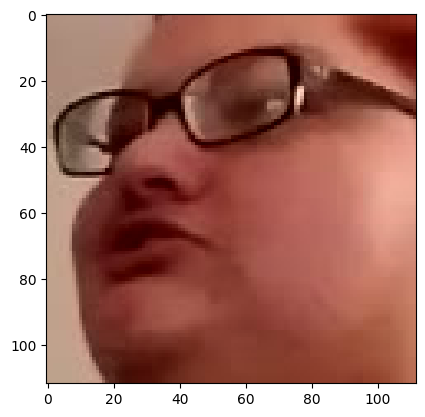

In [ ]:
# load the labels and video in data loader
import random
import pandas as pd
from sklearn.model_selection import train_test_split

header_list = ["file","label"]
labels = pd.read_csv('/content/Gobal_metadata.csv',names=header_list)

#print(labels)
# train_videos = video_files[:int(0.8*len(video_files))]
# valid_videos = video_files[int(0.8*len(video_files)):]
train_videos = video_files[:int(0.6 * len(video_files))]
valid_videos = video_files[int(0.6 * len(video_files)):int(0.8 * len(video_files))]
test_videos = video_files[int(0.8 * len(video_files)):]
print("train : " , len(train_videos))
print("valid : " , len(valid_videos))
print("test : " , len(test_videos))
# train_videos,valid_videos = train_test_split(data,test_size = 0.2) #check it

# print(train_videos)
print("TRAIN: ", "Real:",number_of_real_and_fake_videos(train_videos)[0]," Fake:",number_of_real_and_fake_videos(train_videos)[1])
print("VALID: ", "Real:",number_of_real_and_fake_videos(valid_videos)[0]," Fake:",number_of_real_and_fake_videos(valid_videos)[1])
print("TEST: ", "Real:",number_of_real_and_fake_videos(test_videos)[0]," Fake:",number_of_real_and_fake_videos(test_videos)[1])

im_size = 112
mean = [0.485, 0.456, 0.406]  # defining mean
std = [0.229, 0.224, 0.225]  # defining std.

train_transforms = transforms.Compose([
                                        transforms.ToPILImage(),
                                        transforms.Resize((im_size,im_size)),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean,std)])

test_transforms = transforms.Compose([
                                        transforms.ToPILImage(),
                                        transforms.Resize((im_size,im_size)),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean,std)])
train_data = video_dataset(train_videos,labels,sequence_length = 20,transform = train_transforms)
#print(train_data)
val_data = video_dataset(valid_videos,labels,sequence_length = 20,transform = train_transforms)
test_data = video_dataset(test_videos,labels, sequence_length= 20, transform=test_transforms)
train_loader = DataLoader(train_data,batch_size = 16,shuffle = True,num_workers = 4)
valid_loader = DataLoader(val_data,batch_size = 16,shuffle = True,num_workers = 4)
test_loader = DataLoader(test_data,batch_size=16,shuffle=False, num_workers=4)
image,label = train_data[0]
im_plot(image[0,:,:,:])

Don't run below code just for the reference


In [ ]:
### ading a code to add test set as well:

# from torch.utils.data import Dataset, DataLoader
# import pandas as pd
# from torchvision import transforms

# class VideoDataset(Dataset):
#     def __init__(self, video_names, labels, sequence_length=20, transform=None):
#         self.video_names = video_names
#         self.labels = labels
#         self.sequence_length = sequence_length
#         self.transform = transform

#     def __len__(self):
#         return len(self.video_names)

#     def __getitem__(self, idx):
#         video_path = self.video_names[idx]
#         frames = []
#         label = self.labels.iloc[idx, 1]  # Assuming label column is at index 1
#         if label == 'FAKE':
#             label = 0
#         elif label == 'REAL':
#             label = 1
#         for frame in self.frame_extract(video_path):
#             if self.transform:
#                 frame = self.transform(frame)
#             frames.append(frame)
#             if len(frames) == self.sequence_length:
#                 break
#         return frames, label

#     def frame_extract(self, path):
#         # Your frame extraction logic here
#         pass

# # Load labels
# header_list = ["file", "label"]
# labels = pd.read_csv('/content/Gobal_metadata.csv', names=header_list)

# # Assuming you have lists of video file paths for training, validation, and testing
# train_videos = video_files[:int(0.6 * len(video_files))]
# valid_videos = video_files[int(0.6 * len(video_files)):int(0.8 * len(video_files))]
# test_videos = video_files[int(0.8 * len(video_files)):]

# # Define transformations
# im_size = 112
# mean = [0.485, 0.456, 0.406]
# std = [0.229, 0.224, 0.225]
# transform = transforms.Compose([
#     transforms.ToPILImage(),
#     transforms.Resize((im_size, im_size)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean, std)
# ])

# # Create datasets and data loaders for training, validation, and testing
# train_dataset = VideoDataset(train_videos, labels, transform=transform)
# valid_dataset = VideoDataset(valid_videos, labels, transform=transform)
# test_dataset = VideoDataset(test_videos, labels, transform=transform)

# train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)
# valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False, num_workers=4)
# test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4)


In [ ]:
def count_real_fake_videos(video_names, labels):
    real_count = 0
    fake_count = 0
    for video_name in video_names:
        label = labels[labels['file'] == video_name.split('/')[-1]]['label'].iloc[0]
        if label == 'FAKE':
            fake_count += 1
        elif label == 'REAL':
            real_count += 1
    return real_count, fake_count

# Count real and fake videos in the training set
train_real_fake_count = count_real_fake_videos(train_videos, labels)
print("Training set - Real:", train_real_fake_count[0], " Fake:", train_real_fake_count[1])

# Count real and fake videos in the validation set
valid_real_fake_count = count_real_fake_videos(valid_videos, labels)
print("Validation set - Real:", valid_real_fake_count[0], " Fake:", valid_real_fake_count[1])

# Count real and fake videos in the test set
test_real_fake_count = count_real_fake_videos(test_videos, labels)
print("Test set - Real:", test_real_fake_count[0], " Fake:", test_real_fake_count[1])


Training set - Real: 1989  Fake: 1867
Validation set - Real: 670  Fake: 615
Test set - Real: 642  Fake: 644


## defining the model


In [ ]:
#Model with feature visualization
from torch import nn
from torchvision import models
class Model(nn.Module):
    def __init__(self, num_classes,latent_dim= 2048, lstm_layers=1 , hidden_dim = 2048, bidirectional = False):

        '''
        num_classes: The number of output classes for classification.
        latent_dim: The dimensionality of the latent space.
        lstm_layers: The number of LSTM layers.
        hidden_dim: The dimensionality of the hidden states in the LSTM.
        bidirectional: A boolean indicating whether the LSTM is bidirectional.

        '''

        super(Model, self).__init__()
        model = models.resnext50_32x4d(pretrained = True) #Residual Network CNN
        self.model = nn.Sequential(*list(model.children())[:-2])
        self.lstm = nn.LSTM(latent_dim,hidden_dim, lstm_layers,  bidirectional)
        self.relu = nn.LeakyReLU()
        self.dp = nn.Dropout(0.4)
        self.linear1 = nn.Linear(2048,num_classes)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        batch_size,seq_length, c, h, w = x.shape
        x = x.view(batch_size * seq_length, c, h, w)
        fmap = self.model(x)
        x = self.avgpool(fmap)
        x = x.view(batch_size,seq_length,2048)
        x_lstm,_ = self.lstm(x,None)
        return fmap,self.dp(self.linear1(torch.mean(x_lstm,dim = 1)))

In [ ]:
model = Model(2).cuda()  # Sending model to cuda to train on GPU
a,b = model(torch.from_numpy(np.empty((1,20,3,112,112))).type(torch.cuda.FloatTensor))

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt50_32X4D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-7cdf4587.pth
100%|██████████| 95.8M/95.8M [00:00<00:00, 148MB/s]


In [ ]:
from torch.autograd import Variable
import time
import sys

def train_epoch(epoch, num_epochs, data_loader, model, criterion, optimizer):
    '''
    Funtion to define training loop with given parameters
    '''

    model.train()  # setting model to training mode.
    losses = AverageMeter()  # keep track of losses and accuracies.
    accuracies = AverageMeter()
    t = []
    for i, (inputs, targets) in enumerate(data_loader):  # Iterates through batches of data from the data loader.
        if torch.cuda.is_available():
            targets = targets.type(torch.cuda.LongTensor)
            inputs = inputs.cuda()
        _,outputs = model(inputs)
        loss  = criterion(outputs,targets.type(torch.cuda.LongTensor))
        acc = calculate_accuracy(outputs, targets.type(torch.cuda.LongTensor))
        losses.update(loss.item(), inputs.size(0))  # Performs forward pass, calculates loss, and updates model parameters using backpropagation.
        accuracies.update(acc, inputs.size(0))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        sys.stdout.write(
                "\r[Epoch %d/%d] [Batch %d / %d] [Loss: %f, Acc: %.2f%%]"
                % (
                    epoch,
                    num_epochs,
                    i,
                    len(data_loader),
                    losses.avg,
                    accuracies.avg))
    torch.save(model.state_dict(),'/content/checkpoint.pt')
    return losses.avg,accuracies.avg


def test(epoch,model, data_loader ,criterion):
    '''
    Function to define the testing loop with given parameters.

    '''
    print('Testing')
    model.eval()
    losses = AverageMeter()
    accuracies = AverageMeter()
    pred = []
    true = []
    count = 0
    with torch.no_grad():
        for i, (inputs, targets) in enumerate(data_loader):
            if torch.cuda.is_available():
                targets = targets.cuda().type(torch.cuda.FloatTensor)
                inputs = inputs.cuda()
            _,outputs = model(inputs)
            loss = torch.mean(criterion(outputs, targets.type(torch.cuda.LongTensor)))
            acc = calculate_accuracy(outputs,targets.type(torch.cuda.LongTensor))
            _,p = torch.max(outputs,1)
            true += (targets.type(torch.cuda.LongTensor)).detach().cpu().numpy().reshape(len(targets)).tolist()
            pred += p.detach().cpu().numpy().reshape(len(p)).tolist()
            losses.update(loss.item(), inputs.size(0))
            accuracies.update(acc, inputs.size(0))
            sys.stdout.write(
                    "\r[Batch %d / %d]  [Loss: %f, Acc: %.2f%%]"
                    % (
                        i,
                        len(data_loader),
                        losses.avg,
                        accuracies.avg
                        )
                    )
        print('\nAccuracy {}'.format(accuracies.avg))
    return true,pred,losses.avg,accuracies.avg


class AverageMeter(object):

    """Computes and stores the average and current value"""

    def __init__(self):
        self.reset()
    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count
def calculate_accuracy(outputs, targets):
    batch_size = targets.size(0)

    _, pred = outputs.topk(1, 1, True)
    pred = pred.t()
    correct = pred.eq(targets.view(1, -1))
    n_correct_elems = correct.float().sum().item()
    return 100* n_correct_elems / batch_size

In [ ]:
import seaborn as sn

#Output confusion matrix

def print_confusion_matrix(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)
    print('True positive = ', cm[0][0])
    print('False positive = ', cm[0][1])
    print('False negative = ', cm[1][0])
    print('True negative = ', cm[1][1])
    print('\n')
    df_cm = pd.DataFrame(cm, range(2), range(2))
    sn.set(font_scale=1.4) # for label size
    sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}) # font size
    plt.ylabel('Actual label', size = 20)
    plt.xlabel('Predicted label', size = 20)
    plt.xticks(np.arange(2), ['Fake', 'Real'], size = 16)
    plt.yticks(np.arange(2), ['Fake', 'Real'], size = 16)
    plt.ylim([2, 0])
    plt.show()
    calculated_acc = (cm[0][0]+cm[1][1])/(cm[0][0]+cm[0][1]+cm[1][0]+ cm[1][1])
    print("Calculated Accuracy",calculated_acc*100)


In [ ]:
def plot_loss(train_loss_avg,test_loss_avg,num_epochs):
  loss_train = train_loss_avg
  loss_val = test_loss_avg
  print(num_epochs)
  epochs = range(1,num_epochs+1)
  plt.plot(epochs, loss_train, 'g', label='Training loss')
  plt.plot(epochs, loss_val, 'b', label='validation loss')
  plt.title('Training and Validation loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()
def plot_accuracy(train_accuracy,test_accuracy,num_epochs):
  loss_train = train_accuracy
  loss_val = test_accuracy
  epochs = range(1,num_epochs+1)
  plt.plot(epochs, loss_train, 'g', label='Training accuracy')
  plt.plot(epochs, loss_val, 'b', label='validation accuracy')
  plt.title('Training and Validation accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

## Training the model

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


[Epoch 1/6] [Batch 963 / 964] [Loss: 0.689213, Acc: 56.95%]Testing
[Batch 321 / 322]  [Loss: 0.659817, Acc: 60.47%]
Accuracy 60.46692607003891
[Epoch 2/6] [Batch 963 / 964] [Loss: 0.647820, Acc: 64.70%]Testing
[Batch 321 / 322]  [Loss: 0.582976, Acc: 69.34%]
Accuracy 69.3385214007782
[Epoch 3/6] [Batch 963 / 964] [Loss: 0.596619, Acc: 72.33%]Testing
[Batch 321 / 322]  [Loss: 0.535227, Acc: 74.47%]
Accuracy 74.47470817120623
[Epoch 4/6] [Batch 963 / 964] [Loss: 0.555832, Acc: 74.40%]Testing
[Batch 321 / 322]  [Loss: 0.497944, Acc: 74.71%]
Accuracy 74.70817120622569
[Epoch 5/6] [Batch 963 / 964] [Loss: 0.526113, Acc: 77.15%]Testing
[Batch 321 / 322]  [Loss: 0.513574, Acc: 75.80%]
Accuracy 75.7976653696498
[Epoch 6/6] [Batch 963 / 964] [Loss: 0.482505, Acc: 80.08%]Testing
[Batch 321 / 322]  [Loss: 0.433880, Acc: 81.48%]
Accuracy 81.47859922178988
6


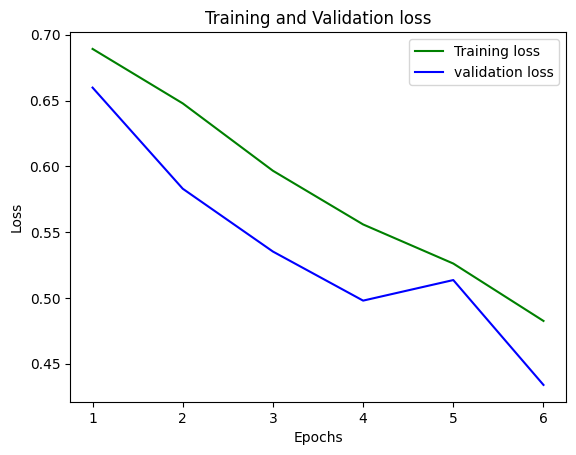

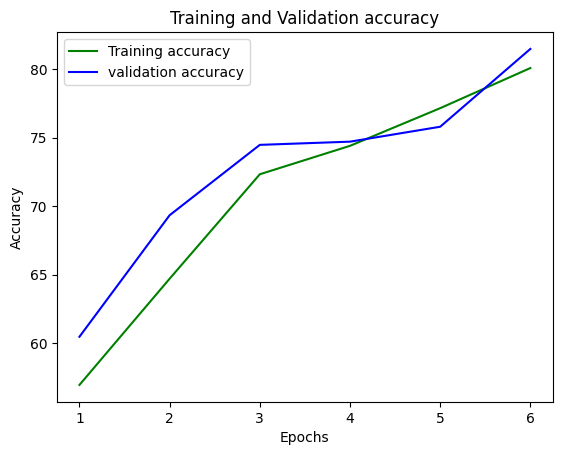

[[511 127]
 [111 536]]
True positive =  511
False positive =  127
False negative =  111
True negative =  536




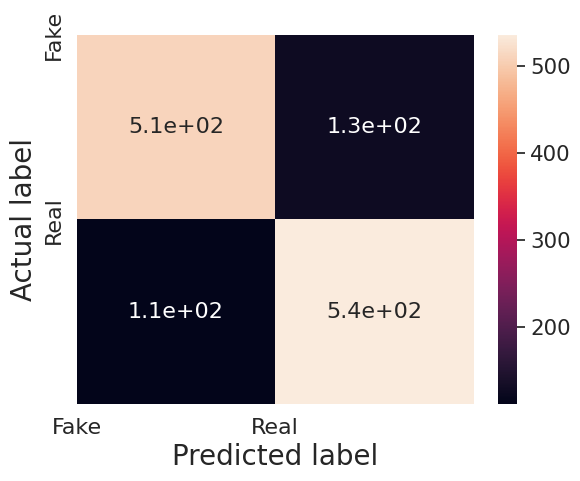

Calculated Accuracy 81.47859922178988


In [ ]:
# training the model.

from sklearn.metrics import confusion_matrix
#learning rate
lr = 1e-5#0.001
#number of epochs
num_epochs = 20

optimizer = torch.optim.Adam(model.parameters(), lr= lr,weight_decay = 1e-5)

#class_weights = torch.from_numpy(np.asarray([1,15])).type(torch.FloatTensor).cuda()
#criterion = nn.CrossEntropyLoss(weight = class_weights).cuda()
criterion = nn.CrossEntropyLoss().cuda()
train_loss_avg =[]
train_accuracy = []
test_loss_avg = []
test_accuracy = []
for epoch in range(1,num_epochs+1):
    l, acc = train_epoch(epoch,num_epochs,train_loader,model,criterion,optimizer)
    train_loss_avg.append(l)
    train_accuracy.append(acc)
    true,pred,tl,t_acc = test(epoch,model,valid_loader,criterion)
    test_loss_avg.append(tl)
    test_accuracy.append(t_acc)
plot_loss(train_loss_avg,test_loss_avg,len(train_loss_avg))
plot_accuracy(train_accuracy,test_accuracy,len(train_accuracy))
print(confusion_matrix(true,pred))
print_confusion_matrix(true,pred)

In [ ]:
plot_loss(train_loss_avg,test_loss_avg,len(train_loss_avg))


In [ ]:
plot_accuracy(train_accuracy,test_accuracy,len(train_accuracy))


[[511 127]
 [111 536]]
True positive =  511
False positive =  127
False negative =  111
True negative =  536




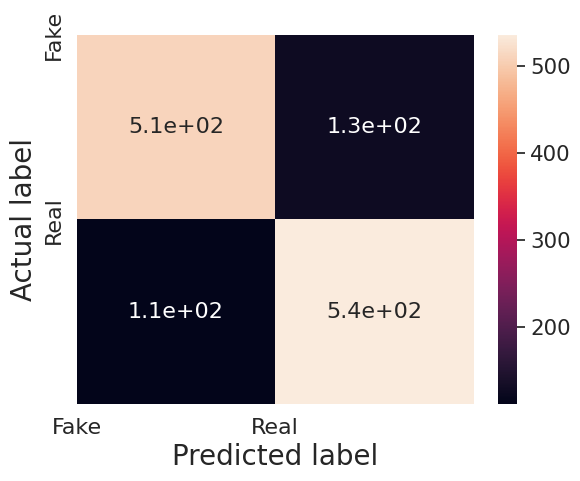

Calculated Accuracy 81.47859922178988


In [ ]:
print(confusion_matrix(true,pred))
print_confusion_matrix(true,pred)

## retraining with 16 batch size and 20 epochs

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


[Epoch 1/20] [Batch 240 / 241] [Loss: 0.337591, Acc: 89.81%]Testing
[Batch 80 / 81]  [Loss: 0.366431, Acc: 84.82%]
Accuracy 84.8249027237354
[Epoch 2/20] [Batch 240 / 241] [Loss: 0.298381, Acc: 91.68%]Testing
[Batch 80 / 81]  [Loss: 0.355325, Acc: 85.84%]
Accuracy 85.83657587548637
[Epoch 3/20] [Batch 240 / 241] [Loss: 0.260102, Acc: 93.57%]Testing
[Batch 80 / 81]  [Loss: 0.355503, Acc: 86.15%]
Accuracy 86.147859922179
[Epoch 4/20] [Batch 240 / 241] [Loss: 0.249497, Acc: 93.80%]Testing
[Batch 80 / 81]  [Loss: 0.366838, Acc: 86.77%]
Accuracy 86.7704280155642
[Epoch 5/20] [Batch 240 / 241] [Loss: 0.230342, Acc: 94.68%]Testing
[Batch 80 / 81]  [Loss: 0.365843, Acc: 87.08%]
Accuracy 87.08171206225681
[Epoch 6/20] [Batch 240 / 241] [Loss: 0.215287, Acc: 95.75%]Testing
[Batch 80 / 81]  [Loss: 0.370582, Acc: 86.77%]
Accuracy 86.7704280155642
[Epoch 7/20] [Batch 240 / 241] [Loss: 0.210054, Acc: 95.67%]Testing
[Batch 80 / 81]  [Loss: 0.378641, Acc: 87.24%]
Accuracy 87.23735408560312
[Epoch 8/20

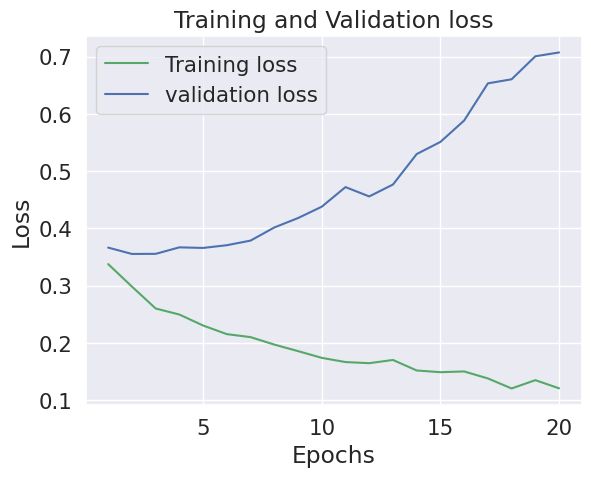

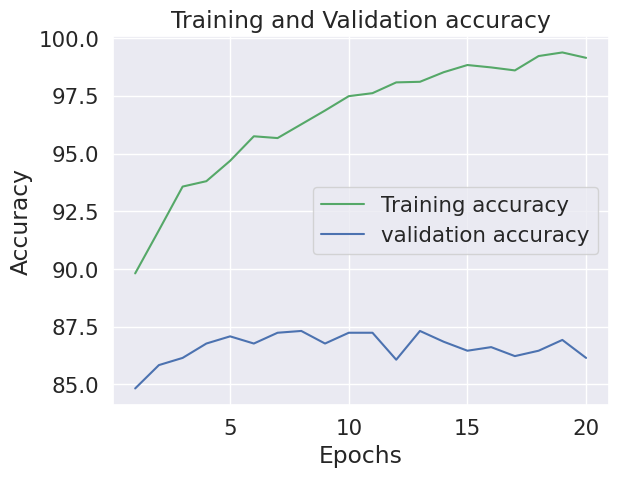

[[527 111]
 [ 67 580]]
True positive =  527
False positive =  111
False negative =  67
True negative =  580




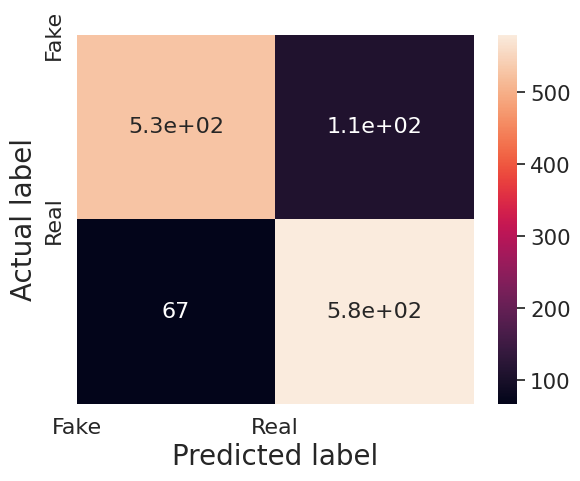

Calculated Accuracy 86.147859922179


In [ ]:
# training the model.

from sklearn.metrics import confusion_matrix
#learning rate
lr = 1e-5#0.001
#number of epochs
num_epochs = 20

optimizer = torch.optim.Adam(model.parameters(), lr= lr,weight_decay = 1e-5)

#class_weights = torch.from_numpy(np.asarray([1,15])).type(torch.FloatTensor).cuda()
#criterion = nn.CrossEntropyLoss(weight = class_weights).cuda()
criterion = nn.CrossEntropyLoss().cuda()
train_loss_avg =[]
train_accuracy = []
test_loss_avg = []
test_accuracy = []
for epoch in range(1,num_epochs+1):
    l, acc = train_epoch(epoch,num_epochs,train_loader,model,criterion,optimizer)
    train_loss_avg.append(l)
    train_accuracy.append(acc)
    true,pred,tl,t_acc = test(epoch,model,valid_loader,criterion)
    test_loss_avg.append(tl)
    test_accuracy.append(t_acc)
plot_loss(train_loss_avg,test_loss_avg,len(train_loss_avg))
plot_accuracy(train_accuracy,test_accuracy,len(train_accuracy))
print(confusion_matrix(true,pred))
print_confusion_matrix(true,pred)

# Loading the trained model

In [ ]:
model = torch.load("/content/drive/MyDrive/checkpoint_model_deepfake.pt")

## For prediction (to do)

In [ ]:

#import libraries
import torch
from torch.autograd import Variable
import time
import os
import sys
import os
from torch import nn
from torchvision import models

In [ ]:
im_size = 112
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]
sm = nn.Softmax()
inv_normalize =  transforms.Normalize(mean=-1*np.divide(mean,std),std=np.divide([1,1,1],std))
def im_convert(tensor):
    """ Display a tensor as an image. """
    image = tensor.to("cpu").clone().detach()
    image = image.squeeze()
    image = inv_normalize(image)
    image = image.numpy()
    image = image.transpose(1,2,0)
    image = image.clip(0, 1)
    cv2.imwrite('./2.png',image*255)
    return image

def predict(model,img,path = './'):
  ''' This function will take the model and image path as input and predict the out as fake or real video.'''

  fmap,logits = model(img.to('cuda'))
  params = list(model.parameters())
  weight_softmax = model.linear1.weight.detach().cpu().numpy()
  logits = sm(logits)
  _,prediction = torch.max(logits,1)
  confidence = logits[:,int(prediction.item())].item()*100
  print('confidence of prediction:',logits[:,int(prediction.item())].item()*100)
  idx = np.argmax(logits.detach().cpu().numpy())
  bz, nc, h, w = fmap.shape
  out = np.dot(fmap[-1].detach().cpu().numpy().reshape((nc, h*w)).T,weight_softmax[idx,:].T)
  predict = out.reshape(h,w)
  predict = predict - np.min(predict)
  predict_img = predict / np.max(predict)
  predict_img = np.uint8(255*predict_img)
  out = cv2.resize(predict_img, (im_size,im_size))
  heatmap = cv2.applyColorMap(out, cv2.COLORMAP_JET)
  img = im_convert(img[:,-1,:,:,:])
  result = heatmap * 0.5 + img*0.8*255
  cv2.imwrite('/content/1.png',result)
  result1 = heatmap * 0.5/255 + img*0.8
  r,g,b = cv2.split(result1)
  result1 = cv2.merge((r,g,b))
  plt.imshow(result1)
  plt.show()
  return [int(prediction.item()),confidence]

### For prediction

In [ ]:
#Code for making prediction
im_size = 112
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
                                        transforms.ToPILImage(),
                                        transforms.Resize((im_size,im_size)),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean,std)])
# path_to_videos = ['/content/drive/My Drive/Balanced_Face_only_data/aagfhgtpmv.mp4',
#                                    '/content/drive/My Drive/Balanced_Face_only_data/aczrgyricp.mp4',
#                                    '/content/drive/My Drive/Balanced_Face_only_data/agdkmztvby.mp4',
#                                    '/content/drive/My Drive/Balanced_Face_only_data/abarnvbtwb.mp4']

# path_to_videos = ['/content/drive/My Drive/Youtube_Face_only_data/000_003.mp4',
#                   '/content/drive/My Drive/Youtube_Face_only_data/000.mp4',
#                   '/content/drive/My Drive/Youtube_Face_only_data/002_006.mp4',
#                   '/content/drive/My Drive/Youtube_Face_only_data/002.mp4'


# ]

# path_to_videos= ["/content/drive/My Drive/DFDC_REAL_Face_only_data/aabqyygbaa.mp4"]

# video_dataset = validation_dataset(path_to_videos,sequence_length = 20,transform = train_transforms)
model = Model(2).cuda()
path_to_model = '/content/drive/MyDrive/checkpoint_model_deepfake.pt'
model.load_state_dict(torch.load(path_to_model))
model.eval()
for i in range(0,len(test_videos)):
  print(test_videos[i])
  prediction = predict(model,test_data[i],'./')
  if prediction[0] == 1:
    print("REAL")
  else:
    print("FAKE")

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt50_32X4D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


/content/FF_Face_only_data/618_629.mp4


AttributeError: 'tuple' object has no attribute 'to'